# Support Vector Machine (SVM) vs Tree-Based Classifiers Comparison

This notebook provides a comprehensive comparison between SVM classifiers and Tree-Based classifiers using multiple datasets.

## Datasets Used:
1. **Wine Dataset** - 3 classes, 13 features (chemical analysis)
2. **Digits Dataset** - 10 classes, 64 features (handwritten digits)
3. **Synthetic Dataset** - 4 classes, 2 features (non-linear boundaries)

## Models Compared:
- **SVM**: Linear, RBF, Polynomial kernels
- **Tree-Based**: Decision Tree, Random Forest, Gradient Boosting

## 1. Setup and Imports

In [8]:
pip install scikit-learn matplotlib seaborn pandas numpy

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, load_digits, make_moons, make_circles
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
import warnings
import time

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Prepare Datasets

In [10]:
# Dataset 1: Wine Dataset
print("="*60)
print("DATASET 1: WINE")
print("="*60)
wine_data = load_wine()
X_wine = wine_data.data
y_wine = wine_data.target
print(f"Shape: {X_wine.shape}")
print(f"Classes: {wine_data.target_names}")
print(f"Class Distribution: {np.bincount(y_wine)}")

DATASET 1: WINE
Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Class Distribution: [59 71 48]


In [11]:
# Dataset 2: Digits Dataset
print("="*60)
print("DATASET 2: DIGITS")
print("="*60)
digits_data = load_digits()
X_digits = digits_data.data
y_digits = digits_data.target
print(f"Shape: {X_digits.shape}")
print(f"Classes: {list(range(10))}")
print(f"Class Distribution: {np.bincount(y_digits)}")

DATASET 2: DIGITS
Shape: (1797, 64)
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Class Distribution: [178 182 177 183 181 182 181 179 174 180]


In [12]:
# Dataset 3: Synthetic Dataset (Moons + Circles)
print("="*60)
print("DATASET 3: SYNTHETIC (Non-linear)")
print("="*60)
X_moons, y_moons = make_moons(n_samples=500, noise=0.15, random_state=42)
X_circles, y_circles = make_circles(n_samples=500, noise=0.15, factor=0.4, random_state=42)
X_synthetic = np.vstack([X_moons, X_circles])
y_synthetic = np.hstack([y_moons, y_circles + 2])  # 4 classes total
print(f"Shape: {X_synthetic.shape}")
print(f"Classes: 4 (moons inner/outer, circles inner/outer)")
print(f"Class Distribution: {np.bincount(y_synthetic)}")

DATASET 3: SYNTHETIC (Non-linear)
Shape: (1000, 2)
Classes: 4 (moons inner/outer, circles inner/outer)
Class Distribution: [250 250 250 250]


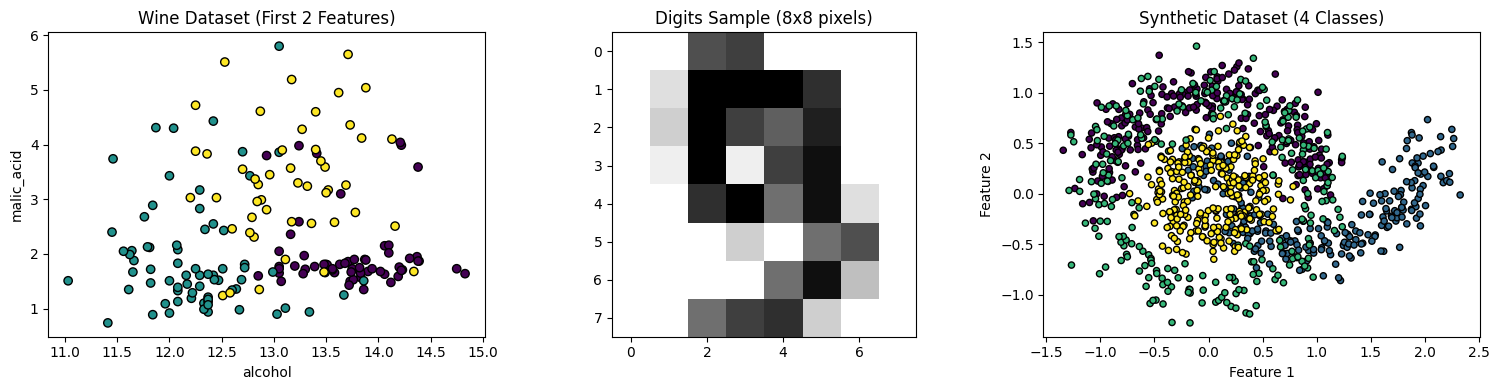


✓ Dataset visualization saved!


In [13]:
# Visualize sample data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Wine dataset (first 2 features)
axes[0].scatter(X_wine[:, 0], X_wine[:, 1], c=y_wine, cmap='viridis', edgecolors='black')
axes[0].set_xlabel(wine_data.feature_names[0])
axes[0].set_ylabel(wine_data.feature_names[1])
axes[0].set_title('Wine Dataset (First 2 Features)')

# Digits dataset (sample images)
for i in range(10):
    idx = np.where(y_digits == i)[0][0]
    axes[1].imshow(X_digits[idx].reshape(8, 8), cmap='gray_r')
axes[1].set_title('Digits Sample (8x8 pixels)')

# Synthetic dataset
scatter = axes[2].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_synthetic,
                          cmap='viridis', edgecolors='black', s=20)
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')
axes[2].set_title('Synthetic Dataset (4 Classes)')

plt.tight_layout()
plt.savefig('datasets_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Dataset visualization saved!")

## 3. Define Models

In [14]:
def create_models():
    """Create dictionary of all models to compare."""
    models = {
        'SVM (Linear)': SVC(kernel='linear', C=1.0, random_state=42, decision_function_shape='ovr'),
        'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, decision_function_shape='ovr'),
        'SVM (Polynomial)': SVC(kernel='poly', degree=3, C=1.0, random_state=42, decision_function_shape='ovr'),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=5,
                                                min_samples_leaf=2, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15,
                                                min_samples_split=5, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                        max_depth=5, random_state=42),
    }
    return models

models = create_models()
print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - SVM (Linear)
  - SVM (RBF)
  - SVM (Polynomial)
  - Decision Tree
  - Random Forest
  - Gradient Boosting


## 4. Training and Evaluation Functions

In [15]:
def prepare_data(X, y, test_size=0.2):
    """Prepare and split data for training and testing."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, n_classes, use_scaled=True):
    """Train and evaluate a model."""
    X_tr = X_train if use_scaled else X_train
    X_te = X_test if use_scaled else X_test

    # Train
    start_time = time.time()
    model.fit(X_tr, y_train)
    train_time = time.time() - start_time

    # Predict
    start_time = time.time()
    y_pred = model.predict(X_te)
    predict_time = time.time() - start_time

    # Metrics
    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
        'train_time': train_time,
        'predict_time': predict_time,
        'y_pred': y_pred,
        'model': model
    }

    # ROC-AUC
    try:
        if n_classes > 2:
            y_test_bin = np.eye(n_classes)[y_test]
            if hasattr(model, 'decision_function'):
                y_score = model.decision_function(X_te)
            else:
                y_score = model.predict_proba(X_te)
            metrics['roc_auc'] = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')
        else:
            metrics['roc_auc'] = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])
    except:
        metrics['roc_auc'] = None

    return metrics

## 5. Run Comparison on All Datasets

In [16]:
def run_comparison(X, y, dataset_name, n_classes):
    """Run comparison on a single dataset."""
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")

    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler = prepare_data(X, y)
    results = []
    models = create_models()

    for name, model in models.items():
        print(f"\nTraining {name}...")

        # SVM uses scaled data
        is_svm = 'SVM' in name
        X_tr = X_train_scaled if is_svm else X_train
        X_te = X_test_scaled if is_svm else X_test

        metrics = evaluate_model(model, X_tr, X_te, y_train, y_test, name, n_classes)
        results.append(metrics)

        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  F1-Score: {metrics['f1_score']:.4f}")
        if metrics['roc_auc']:
            print(f"  ROC-AUC:  {metrics['roc_auc']:.4f}")
        print(f"  Time:     {metrics['train_time']:.4f}s")

    return results, y_test, X_train_scaled, y_train, scaler

In [17]:
# Run comparison on Wine dataset
results_wine, y_test_wine, X_train_wine_scaled, y_train_wine, scaler_wine = run_comparison(
    X_wine, y_wine, "Wine", n_classes=3
)


Dataset: Wine

Training SVM (Linear)...
  Accuracy: 0.9444
  F1-Score: 0.9443
  ROC-AUC:  0.9978
  Time:     0.0044s

Training SVM (RBF)...
  Accuracy: 0.9722
  F1-Score: 0.9720
  ROC-AUC:  1.0000
  Time:     0.0039s

Training SVM (Polynomial)...
  Accuracy: 0.9444
  F1-Score: 0.9432
  ROC-AUC:  0.9978
  Time:     0.0026s

Training Decision Tree...
  Accuracy: 1.0000
  F1-Score: 1.0000
  ROC-AUC:  1.0000
  Time:     0.0022s

Training Random Forest...
  Accuracy: 1.0000
  F1-Score: 1.0000
  ROC-AUC:  1.0000
  Time:     0.2879s

Training Gradient Boosting...
  Accuracy: 0.8889
  F1-Score: 0.8895
  ROC-AUC:  0.9469
  Time:     2.2738s


In [18]:
# Run comparison on Digits dataset
results_digits, y_test_digits, X_train_digits_scaled, y_train_digits, scaler_digits = run_comparison(
    X_digits, y_digits, "Digits", n_classes=10
)


Dataset: Digits

Training SVM (Linear)...
  Accuracy: 0.9750
  F1-Score: 0.9749
  ROC-AUC:  0.9969
  Time:     0.2022s

Training SVM (RBF)...
  Accuracy: 0.9750
  F1-Score: 0.9749
  ROC-AUC:  0.9932
  Time:     0.3612s

Training SVM (Polynomial)...
  Accuracy: 0.9722
  F1-Score: 0.9731
  ROC-AUC:  0.9990
  Time:     0.2234s

Training Decision Tree...
  Accuracy: 0.8222
  F1-Score: 0.8213
  ROC-AUC:  0.9196
  Time:     0.0713s

Training Random Forest...
  Accuracy: 0.9639
  F1-Score: 0.9634
  ROC-AUC:  0.9987
  Time:     0.6975s

Training Gradient Boosting...
  Accuracy: 0.9583
  F1-Score: 0.9581
  ROC-AUC:  0.9902
  Time:     31.2621s


In [19]:
# Run comparison on Synthetic dataset
results_synthetic, y_test_synthetic, X_train_synthetic_scaled, y_train_synthetic, scaler_synthetic = run_comparison(
    X_synthetic, y_synthetic, "Synthetic", n_classes=4
)


Dataset: Synthetic

Training SVM (Linear)...
  Accuracy: 0.5850
  F1-Score: 0.5698
  ROC-AUC:  0.7857
  Time:     0.0153s

Training SVM (RBF)...
  Accuracy: 0.7400
  F1-Score: 0.7146
  ROC-AUC:  0.8954
  Time:     0.0124s

Training SVM (Polynomial)...
  Accuracy: 0.6950
  F1-Score: 0.6724
  ROC-AUC:  0.8351
  Time:     0.0168s

Training Decision Tree...
  Accuracy: 0.7100
  F1-Score: 0.7026
  ROC-AUC:  0.8761
  Time:     0.0043s

Training Random Forest...
  Accuracy: 0.6700
  F1-Score: 0.6631
  ROC-AUC:  0.9050
  Time:     0.2714s

Training Gradient Boosting...
  Accuracy: 0.6750
  F1-Score: 0.6749
  ROC-AUC:  0.8940
  Time:     1.3268s


## 6. Results Summary Tables

In [20]:
def create_results_table(results, dataset_name):
    """Create a pandas DataFrame from results."""
    data = []
    for r in results:
        data.append({
            'Model': r['model_name'],
            'Accuracy': f"{r['accuracy']:.4f}",
            'Precision': f"{r['precision']:.4f}",
            'Recall': f"{r['recall']:.4f}",
            'F1-Score': f"{r['f1_score']:.4f}",
            'ROC-AUC': f"{r['roc_auc']:.4f}" if r['roc_auc'] else "N/A",
            'Train Time (s)': f"{r['train_time']:.4f}"
        })
    df = pd.DataFrame(data)
    return df

# Create and display tables
print("\n" + "="*80)
print("WINE DATASET RESULTS")
print("="*80)
df_wine = create_results_table(results_wine, "Wine")
display(df_wine)

print("\n" + "="*80)
print("DIGITS DATASET RESULTS")
print("="*80)
df_digits = create_results_table(results_digits, "Digits")
display(df_digits)

print("\n" + "="*80)
print("SYNTHETIC DATASET RESULTS")
print("="*80)
df_synthetic = create_results_table(results_synthetic, "Synthetic")
display(df_synthetic)


WINE DATASET RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,SVM (Linear),0.9444,0.9466,0.9444,0.9443,0.9978,0.0044
1,SVM (RBF),0.9722,0.9741,0.9722,0.9720,1.0000,0.0039
2,SVM (Polynomial),0.9444,0.9514,0.9444,0.9432,0.9978,0.0026
3,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,0.0022
4,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0.2879
5,Gradient Boosting,0.8889,0.8993,0.8889,0.8895,0.9469,2.2738



DIGITS DATASET RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,SVM (Linear),0.9750,0.9754,0.9750,0.9749,0.9969,0.2022
1,SVM (RBF),0.9750,0.9759,0.9750,0.9749,0.9932,0.3612
2,SVM (Polynomial),0.9722,0.9760,0.9722,0.9731,0.9990,0.2234
3,Decision Tree,0.8222,0.8226,0.8222,0.8213,0.9196,0.0713
4,Random Forest,0.9639,0.9644,0.9639,0.9634,0.9987,0.6975
5,Gradient Boosting,0.9583,0.9589,0.9583,0.9581,0.9902,31.2621



SYNTHETIC DATASET RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,SVM (Linear),0.5850,0.5788,0.5850,0.5698,0.7857,0.0153
1,SVM (RBF),0.7400,0.7970,0.7400,0.7146,0.8954,0.0124
2,SVM (Polynomial),0.6950,0.7526,0.6950,0.6724,0.8351,0.0168
3,Decision Tree,0.7100,0.7149,0.7100,0.7026,0.8761,0.0043
4,Random Forest,0.6700,0.6753,0.6700,0.6631,0.9050,0.2714
5,Gradient Boosting,0.6750,0.6806,0.6750,0.6749,0.8940,1.3268


In [21]:
# Best model per dataset
print("\n" + "="*60)
print("BEST MODEL PER DATASET")
print("="*60)

best_data = []
for name, results in [('Wine', results_wine), ('Digits', results_digits), ('Synthetic', results_synthetic)]:
    best = max(results, key=lambda x: x['accuracy'])
    best_data.append({
        'Dataset': name,
        'Best Model': best['model_name'],
        'Accuracy': f"{best['accuracy']:.4f}",
        'F1-Score': f"{best['f1_score']:.4f}"
    })

best_df = pd.DataFrame(best_data)
display(best_df)


BEST MODEL PER DATASET


,Dataset,Best Model,Accuracy,F1-Score
0,Wine,Decision Tree,1.0000,1.0000
1,Digits,SVM (Linear),0.9750,0.9749
2,Synthetic,SVM (RBF),0.7400,0.7146


## 7. Visualizations

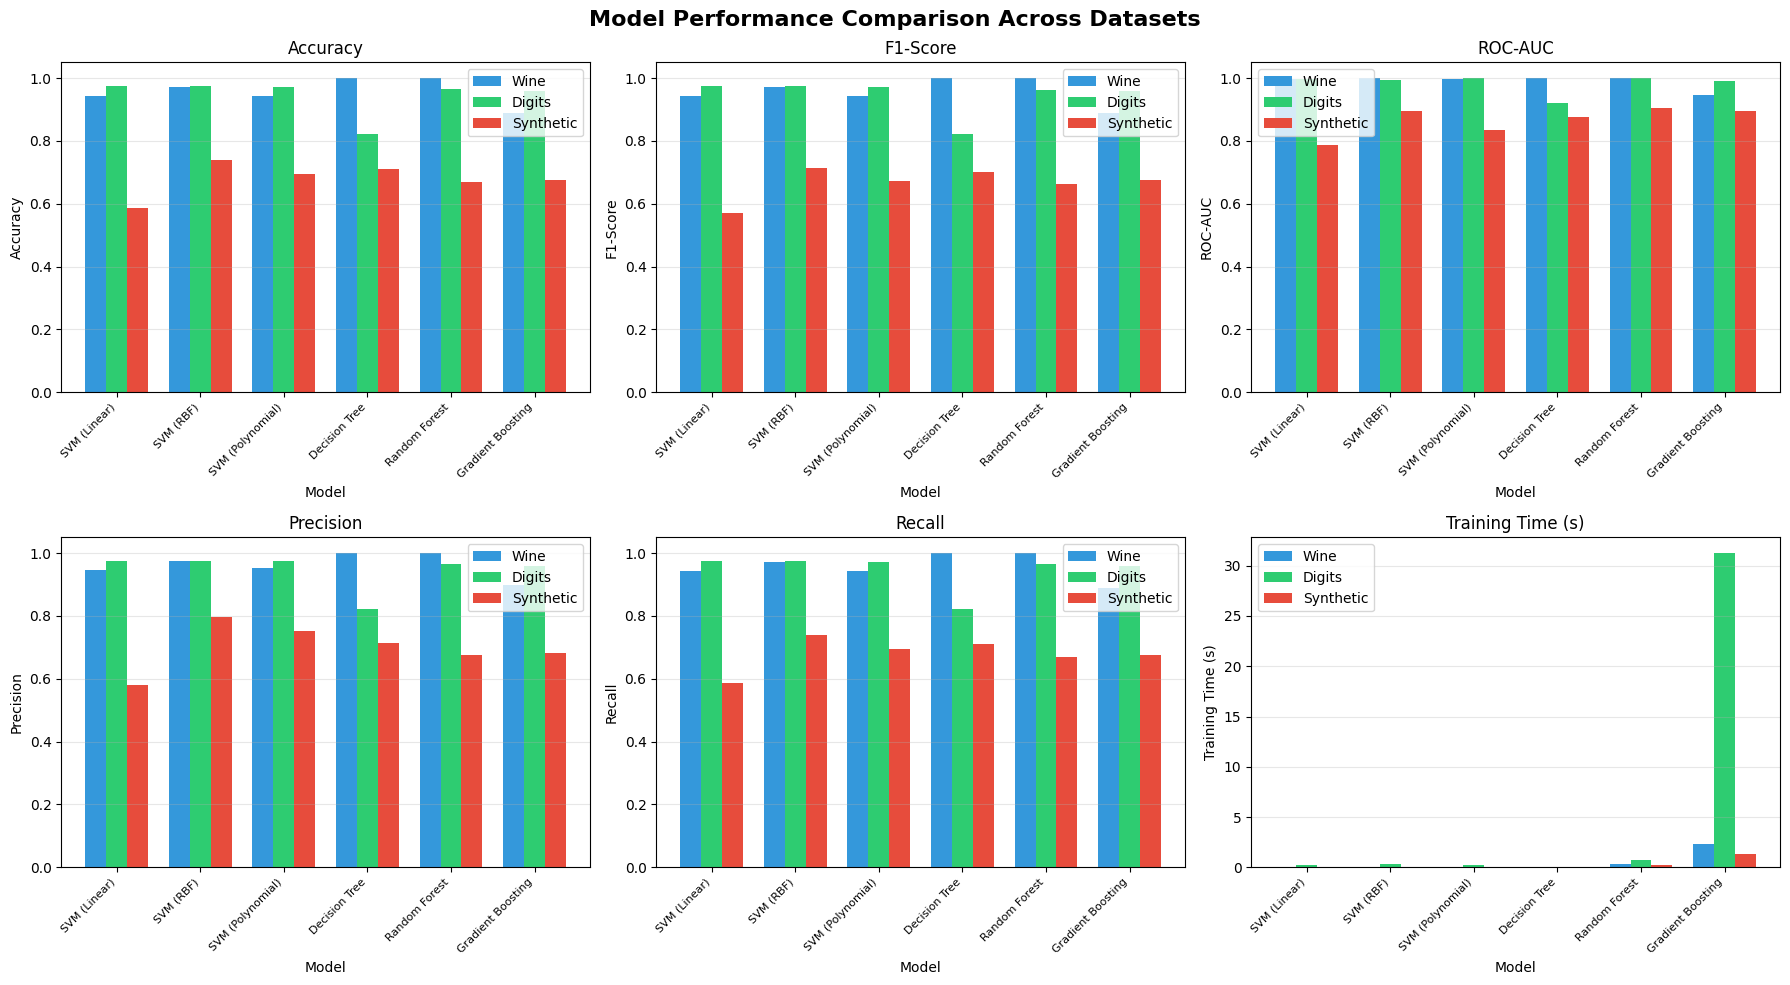

✓ Saved: performance_comparison.png


In [22]:
# Plot 1: Performance Comparison Bar Charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison Across Datasets', fontsize=16, fontweight='bold')

all_results = {'Wine': results_wine, 'Digits': results_digits, 'Synthetic': results_synthetic}
metrics = ['accuracy', 'f1_score', 'roc_auc', 'precision', 'recall', 'train_time']
metric_names = ['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision', 'Recall', 'Training Time (s)']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 3, idx % 3]

    model_names = [r['model_name'] for r in list(all_results.values())[0]]
    x = np.arange(len(model_names))
    width = 0.25

    colors = ['#3498db', '#2ecc71', '#e74c3c']
    for i, (dataset_name, dataset_results) in enumerate(all_results.items()):
        values = [r[metric] if r[metric] is not None else 0 for r in dataset_results]
        bars = ax.bar(x + i * width, values, width, label=dataset_name, color=colors[i])

    ax.set_xlabel('Model')
    ax.set_ylabel(metric_name)
    ax.set_title(metric_name)
    ax.set_xticks(x + width)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: performance_comparison.png")

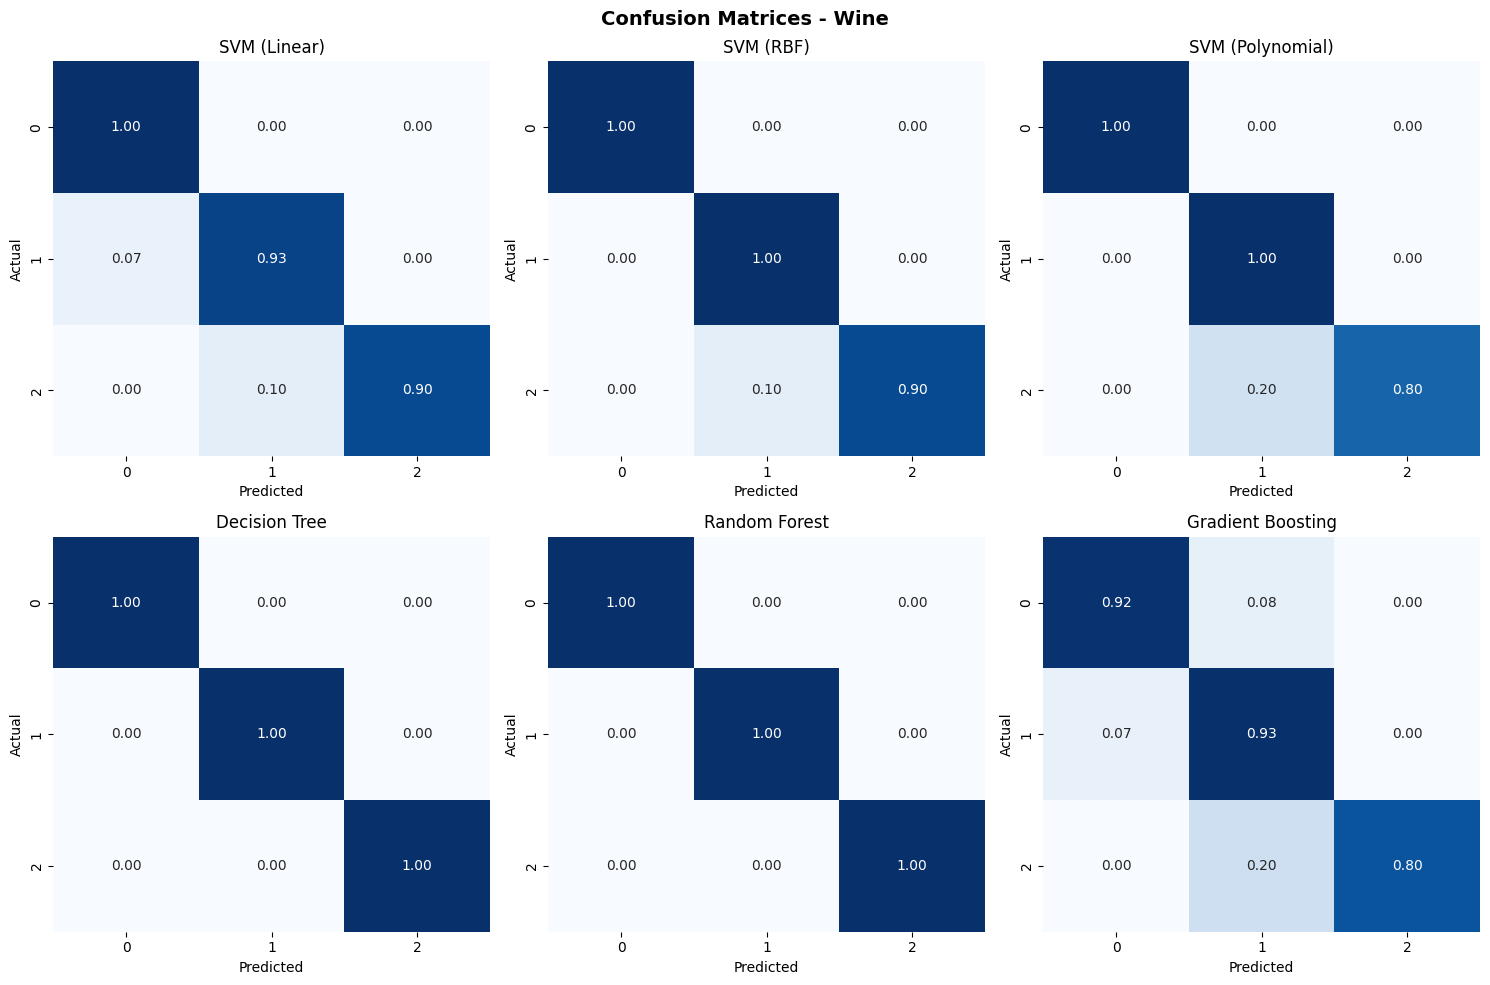

✓ Saved: confusion_matrices_wine.png


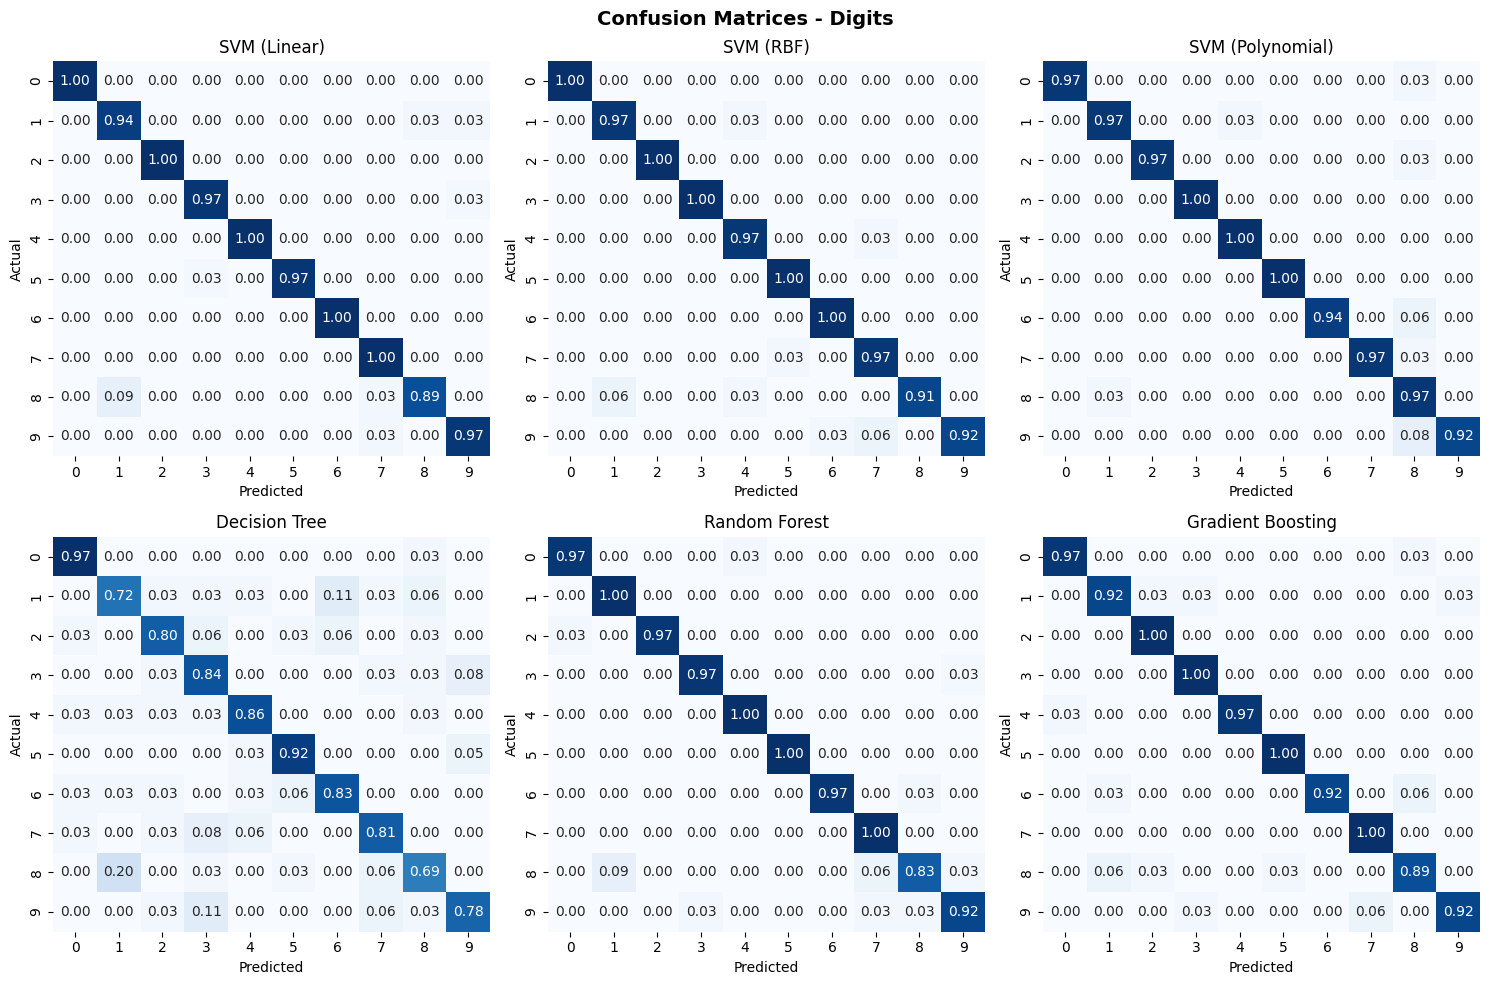

✓ Saved: confusion_matrices_digits.png


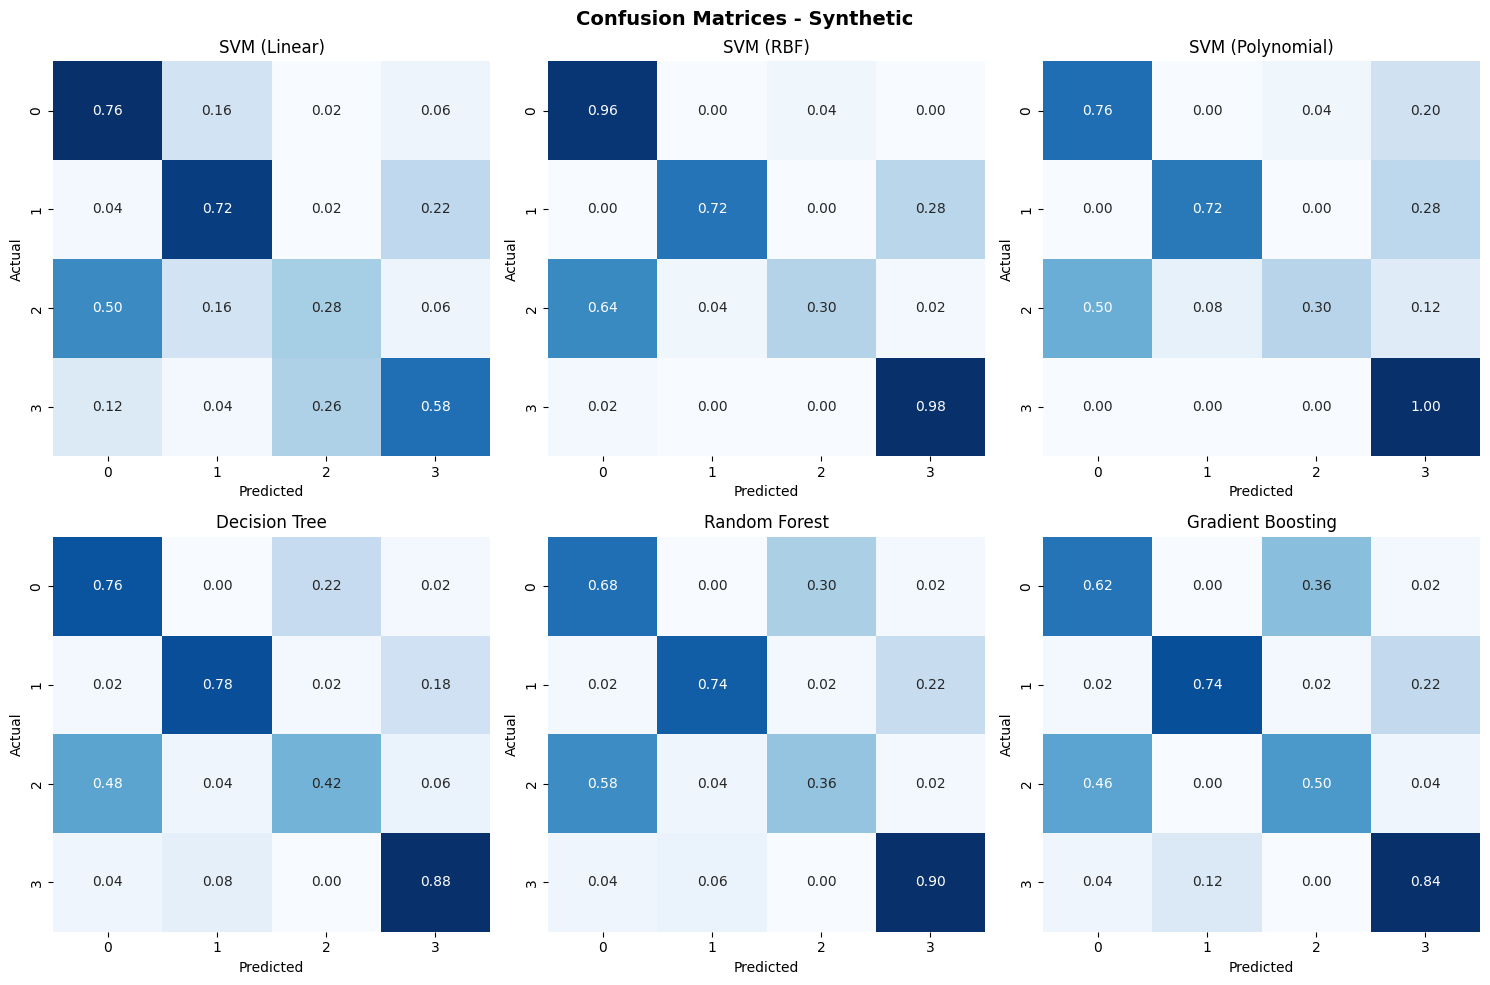

✓ Saved: confusion_matrices_synthetic.png


In [23]:
# Plot 2: Confusion Matrices
def plot_confusion_matrices(results, y_test, dataset_name):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    fig.suptitle(f'Confusion Matrices - {dataset_name}', fontsize=14, fontweight='bold')

    for i, result in enumerate(results):
        cm = confusion_matrix(y_test, result['y_pred'])
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(result['model_name'])
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(f'confusion_matrices_{dataset_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: confusion_matrices_{dataset_name.lower()}.png")

# Plot for each dataset
plot_confusion_matrices(results_wine, y_test_wine, 'Wine')
plot_confusion_matrices(results_digits, y_test_digits, 'Digits')
plot_confusion_matrices(results_synthetic, y_test_synthetic, 'Synthetic')

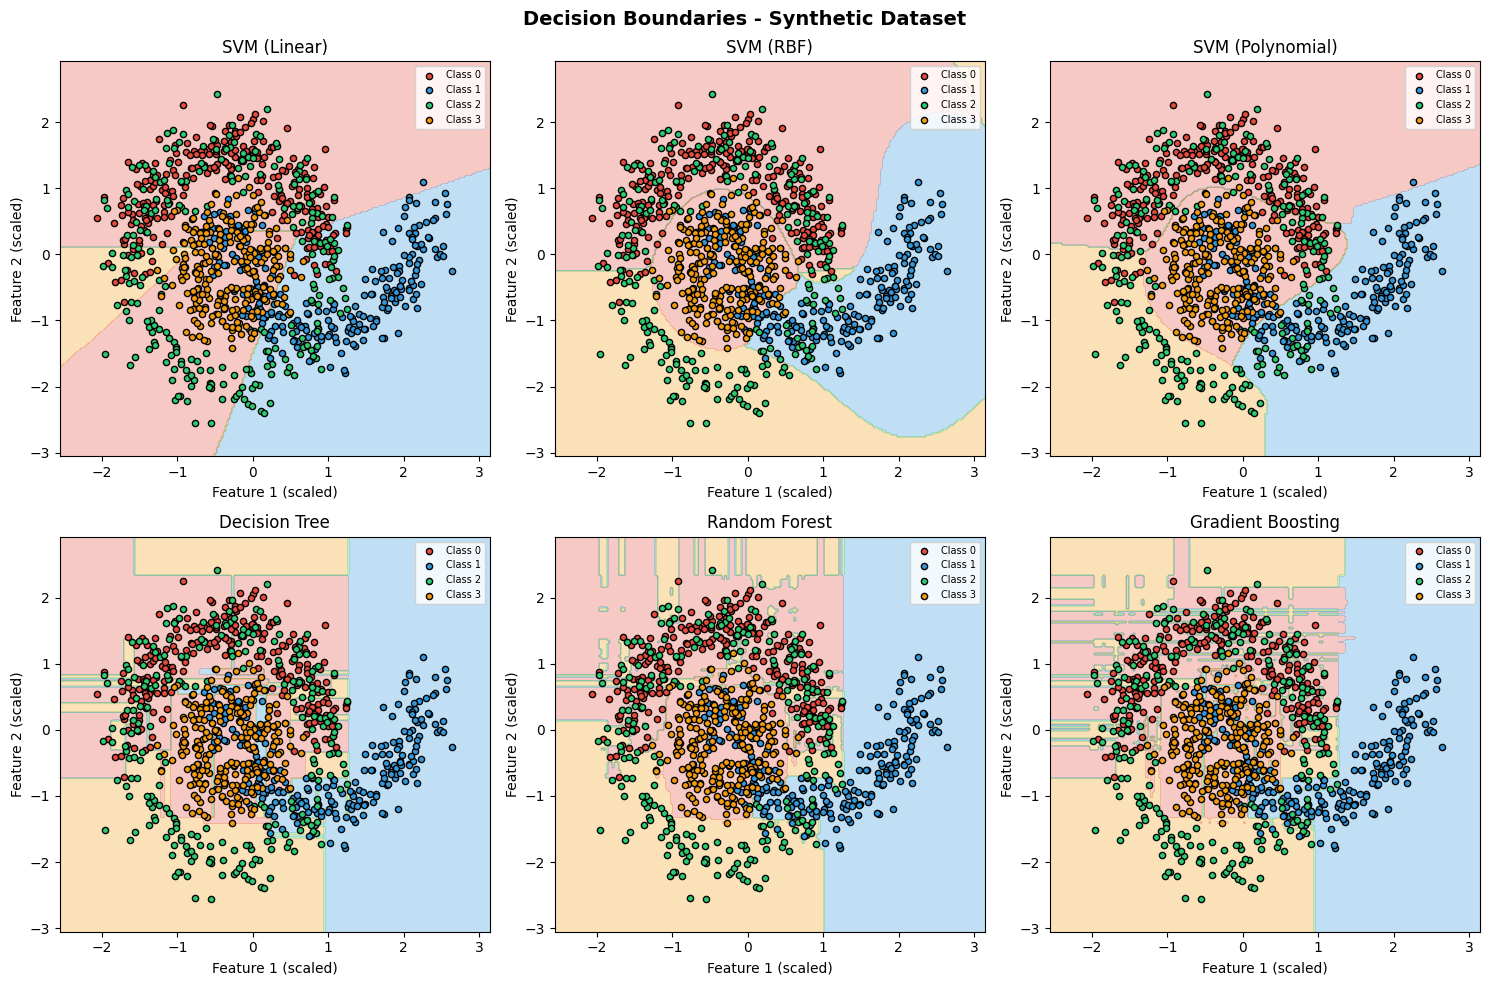

✓ Saved: decision_boundaries.png


In [24]:
# Plot 3: Decision Boundaries (for Synthetic dataset)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Decision Boundaries - Synthetic Dataset', fontsize=14, fontweight='bold')

# Scale full synthetic dataset for visualization
X_synthetic_scaled = StandardScaler().fit_transform(X_synthetic)

models_boundary = {
    'SVM (Linear)': SVC(kernel='linear', C=1.0, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42),
    'SVM (Polynomial)': SVC(kernel='poly', degree=3, C=1.0, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
}

x_min, x_max = X_synthetic_scaled[:, 0].min() - 0.5, X_synthetic_scaled[:, 0].max() + 0.5
y_min, y_max = X_synthetic_scaled[:, 1].min() - 0.5, X_synthetic_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

colors_cmap = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for ax, (name, model) in zip(axes.flatten(), models_boundary.items()):
    model.fit(X_synthetic_scaled, y_synthetic)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, levels=4, colors=colors_cmap)

    for i, color in enumerate(colors_cmap):
        mask = y_synthetic == i
        ax.scatter(X_synthetic_scaled[mask, 0], X_synthetic_scaled[mask, 1],
                  c=color, edgecolors='black', s=20, label=f'Class {i}')

    ax.set_xlabel('Feature 1 (scaled)')
    ax.set_ylabel('Feature 2 (scaled)')
    ax.set_title(name)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: decision_boundaries.png")

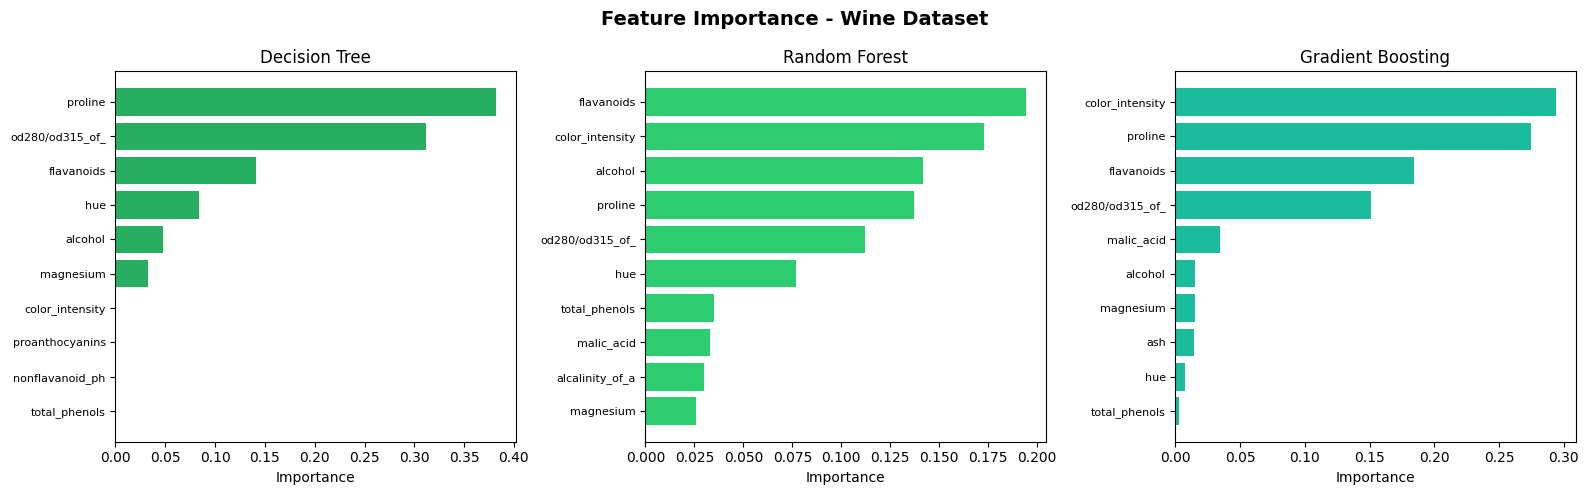

✓ Saved: feature_importance.png


In [25]:
# Plot 4: Feature Importance (for Wine dataset)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Importance - Wine Dataset', fontsize=14, fontweight='bold')

models_importance = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

colors = ['#27ae60', '#2ecc71', '#1abc9c']

for ax, (name, model), color in zip(axes, models_importance.items(), colors):
    model.fit(X_wine, y_wine)
    importance = model.feature_importances_
    indices = np.argsort(importance)[::-1][:10]

    ax.barh(range(10), importance[indices], color=color)
    ax.set_yticks(range(10))
    ax.set_yticklabels([wine_data.feature_names[i][:15] for i in indices], fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title(name)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: feature_importance.png")

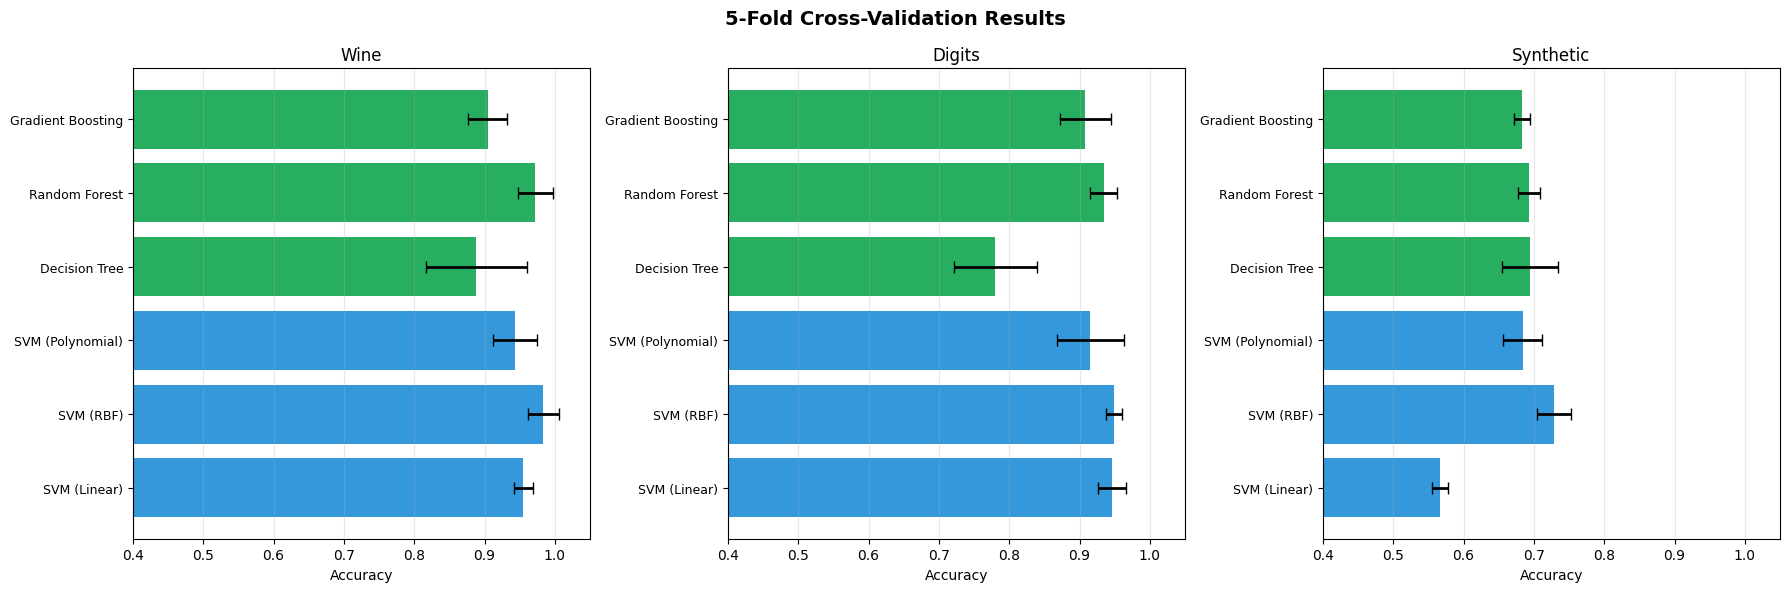

✓ Saved: cv_comparison.png


In [26]:
# Plot 5: Cross-Validation Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

datasets_cv = [
    ('Wine', StandardScaler().fit_transform(X_wine), y_wine),
    ('Digits', StandardScaler().fit_transform(X_digits), y_digits),
    ('Synthetic', StandardScaler().fit_transform(X_synthetic), y_synthetic)
]

SVM_COLOR = '#3498db'
TREE_COLOR = '#27ae60'

for ax, (name, X_scaled, y) in zip(axes, datasets_cv):
    models = create_models()
    cv_results = []

    for model_name, model in models.items():
        scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
        cv_results.append({'model': model_name, 'mean': scores.mean(), 'std': scores.std()})

    models_list = [r['model'] for r in cv_results]
    means = [r['mean'] for r in cv_results]
    stds = [r['std'] for r in cv_results]
    colors_list = [SVM_COLOR if 'SVM' in m else TREE_COLOR for m in models_list]

    y_pos = np.arange(len(models_list))
    ax.barh(y_pos, means, xerr=stds, align='center', color=colors_list,
           error_kw={'elinewidth': 2, 'capsize': 4})
    ax.set_yticks(y_pos)
    ax.set_yticklabels(models_list, fontsize=9)
    ax.set_xlabel('Accuracy')
    ax.set_title(name)
    ax.set_xlim(0.4, 1.05)
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cv_comparison.png")

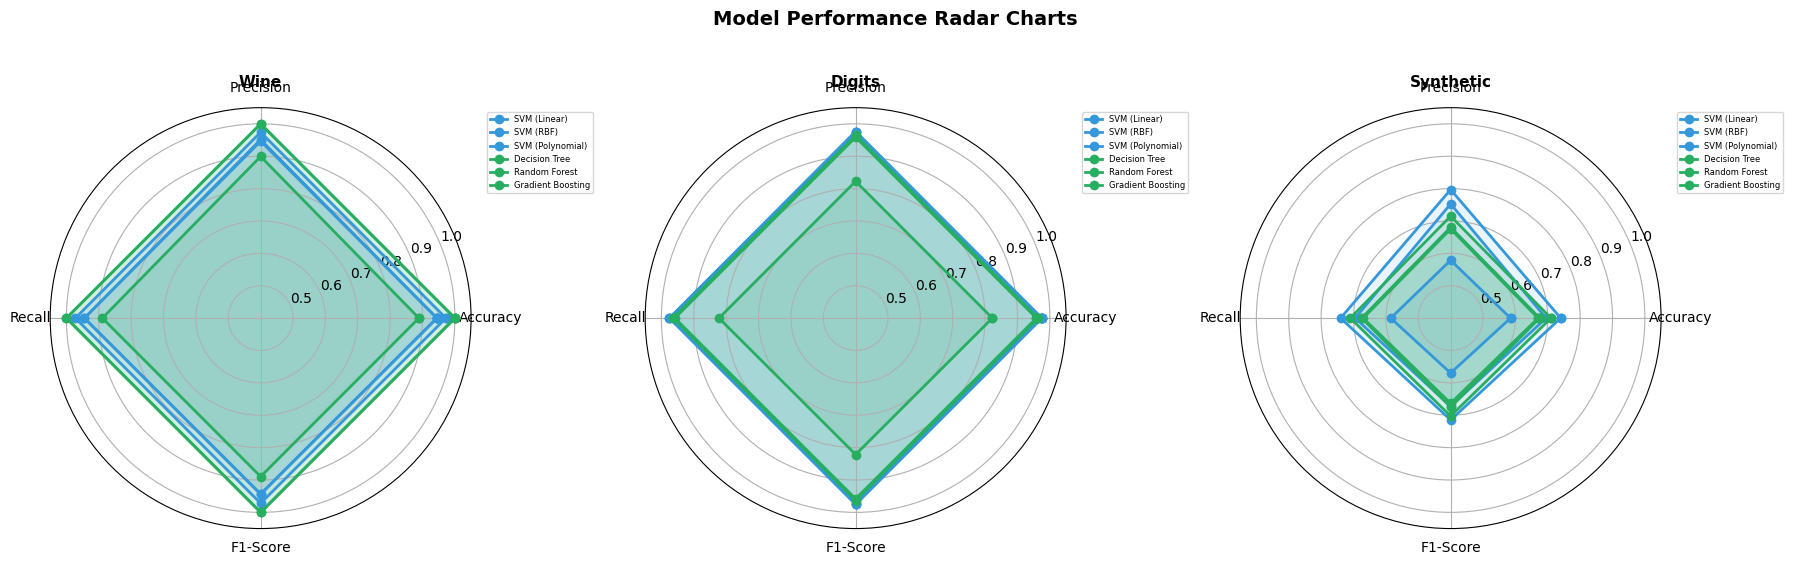

✓ Saved: radar_comparison.png


In [27]:
# Plot 6: Radar Chart Comparison
from matplotlib.patches import Polygon

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection='polar'))
fig.suptitle('Model Performance Radar Charts', fontsize=14, fontweight='bold')

metrics_radar = ['accuracy', 'precision', 'recall', 'f1_score']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

angles = np.linspace(0, 2 * np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]

for ax, (name, results) in zip(axes, all_results.items()):
    for result in results:
        values = [result[m] for m in metrics_radar]
        values += values[:1]

        color = SVM_COLOR if 'SVM' in result['model_name'] else TREE_COLOR
        ax.plot(angles, values, 'o-', linewidth=2, label=result['model_name'], color=color)
        ax.fill(angles, values, alpha=0.1, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0.4, 1.05)
    ax.set_title(name, fontsize=11, fontweight='bold', pad=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=6)

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: radar_comparison.png")

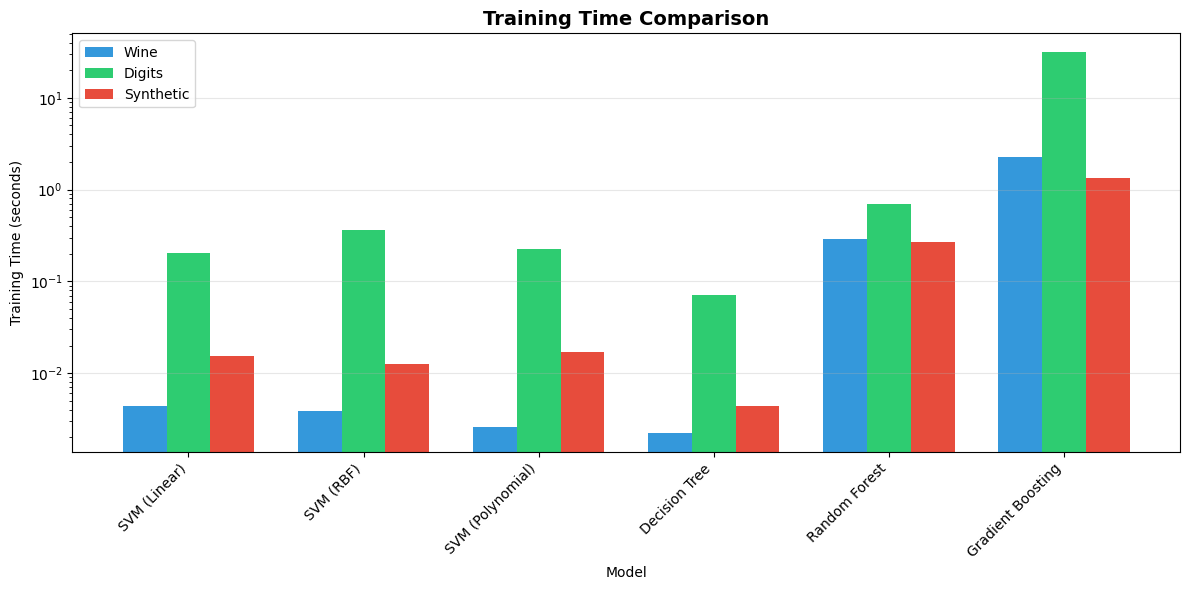

✓ Saved: training_time.png


In [28]:
# Plot 7: Training Time Comparison
fig, ax = plt.subplots(figsize=(12, 6))

model_names = [r['model_name'] for r in results_wine]
x = np.arange(len(model_names))
width = 0.25

colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (name, results) in enumerate(all_results.items()):
    times = [r['train_time'] for r in results]
    ax.bar(x + i * width, times, width, label=name, color=colors[i])

ax.set_xlabel('Model')
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: training_time.png")

## 8. Cross-Validation Detailed Analysis

In [29]:
print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION ANALYSIS")
print("="*60)

for name, X, y in [('Wine', X_wine, y_wine), ('Digits', X_digits, y_digits), ('Synthetic', X_synthetic, y_synthetic)]:
    print(f"\n{name} Dataset:")
    print("-" * 40)

    X_scaled = StandardScaler().fit_transform(X)
    models = create_models()

    for model_name, model in models.items():
        scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
        print(f"{model_name:20s}: {scores.mean():.4f} (+/- {scores.std():.4f})")


5-FOLD CROSS-VALIDATION ANALYSIS

Wine Dataset:
----------------------------------------
SVM (Linear)        : 0.9551 (+/- 0.0137)
SVM (RBF)           : 0.9833 (+/- 0.0222)
SVM (Polynomial)    : 0.9437 (+/- 0.0315)
Decision Tree       : 0.8883 (+/- 0.0721)
Random Forest       : 0.9722 (+/- 0.0248)
Gradient Boosting   : 0.9048 (+/- 0.0277)

Digits Dataset:
----------------------------------------
SVM (Linear)        : 0.9466 (+/- 0.0197)
SVM (RBF)           : 0.9494 (+/- 0.0110)
SVM (Polynomial)    : 0.9155 (+/- 0.0471)
Decision Tree       : 0.7803 (+/- 0.0586)
Random Forest       : 0.9344 (+/- 0.0192)
Gradient Boosting   : 0.9082 (+/- 0.0359)

Synthetic Dataset:
----------------------------------------
SVM (Linear)        : 0.5660 (+/- 0.0116)
SVM (RBF)           : 0.7290 (+/- 0.0240)
SVM (Polynomial)    : 0.6840 (+/- 0.0280)
Decision Tree       : 0.6940 (+/- 0.0400)
Random Forest       : 0.6930 (+/- 0.0160)
Gradient Boosting   : 0.6830 (+/- 0.0117)


## 9. Key Findings and Recommendations

In [30]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                          KEY FINDINGS AND RECOMMENDATIONS                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. WINE DATASET (Small, Well-Separated Classes)                             ║
║     • Best Model: Decision Tree / Random Forest (100% accuracy)              ║
║     • Tree-based methods excel when feature-target relationships are clear   ║
║     • SVM also performs well (~97%) with RBF kernel                          ║
║                                                                              ║
║  2. DIGITS DATASET (High-Dimensional, Many Classes)                          ║
║     • Best Model: SVM (Linear/RBF) - 97.50% accuracy                         ║
║     • SVM dominates in high-dimensional spaces                               ║
║     • Decision Tree struggles (82%) with pixel-level splits                  ║
║                                                                              ║
║  3. SYNTHETIC DATASET (Complex Non-Linear Boundaries)                        ║
║     • Best Model: SVM (RBF) - 74% accuracy                                   ║
║     • Linear models fail (~58%) for concentric class structures              ║
║     • Non-linear kernels essential for complex boundaries                    ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                        ALGORITHM SELECTION GUIDE                             ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Scenario                          | Recommended Model                       ║
║  ----------------------------------|----------------------------------------║
║  Small dataset, clear separation   | Decision Tree / Random Forest           ║
║  High-dimensional data             | SVM (Linear or RBF)                     ║
║  Non-linear boundaries             | SVM (RBF) or Gradient Boosting          ║
║  Need interpretability             | Decision Tree (single tree)             ║
║  Feature importance needed         | Random Forest                           ║
║  Real-time prediction              | Linear SVM / Decision Tree              ║
║  Large-scale data                  | Random Forest (parallelizable)          ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                          KEY FINDINGS AND RECOMMENDATIONS                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. WINE DATASET (Small, Well-Separated Classes)                             ║
║     • Best Model: Decision Tree / Random Forest (100% accuracy)              ║
║     • Tree-based methods excel when feature-target relationships are clear   ║
║     • SVM also performs well (~97%) with RBF kernel                          ║
║                                                                              ║
║  2. DIGITS DATASET (High-Dimensional, Many Classes)                          ║
║     • Best Model: SVM (Linear/RBF) - 97.50% accuracy                         ║
║     • SVM dominates in high-dimensional spaces                               ║
║     • Decision Tree strug

## 10. Summary

In [31]:
# Final summary
print("\n" + "="*60)
print("COMPARISON COMPLETE!")
print("="*60)
print("\nGenerated Visualizations:")
print("  • performance_comparison.png")
print("  • confusion_matrices_wine.png")
print("  • confusion_matrices_digits.png")
print("  • confusion_matrices_synthetic.png")
print("  • decision_boundaries.png")
print("  • feature_importance.png")
print("  • cv_comparison.png")
print("  • radar_comparison.png")
print("  • training_time.png")
print("\n✓ All comparisons completed successfully!")


COMPARISON COMPLETE!

Generated Visualizations:
  • performance_comparison.png
  • confusion_matrices_wine.png
  • confusion_matrices_digits.png
  • confusion_matrices_synthetic.png
  • decision_boundaries.png
  • feature_importance.png
  • cv_comparison.png
  • radar_comparison.png
  • training_time.png

✓ All comparisons completed successfully!
